In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split , cross_val_score 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.datasets import make_regression, load_diabetes
from sklearn.svm import SVR
from sklearn.ensemble import  VotingRegressor
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")





**Базовая линейная регрессия**

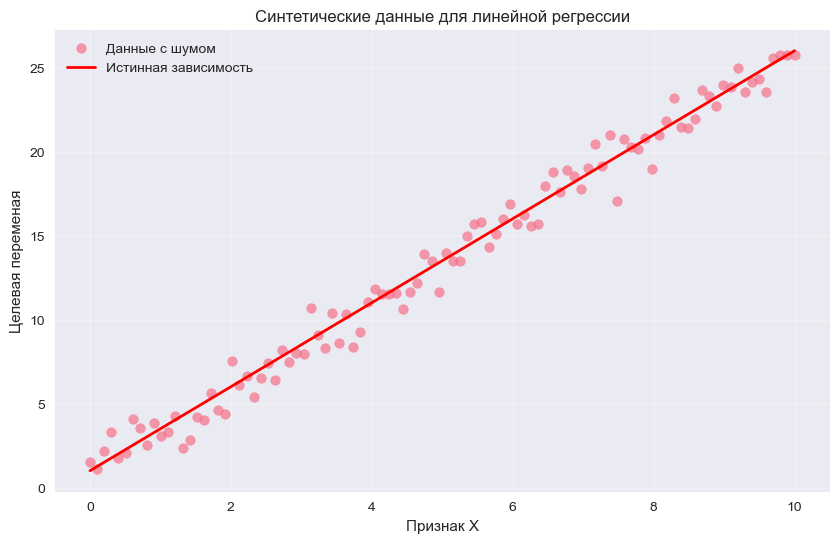

Оцененные параметры модели:
Смещение (intercept): 0.827
Коэффициент (slope): 2.514
Истинные параметры: смещение = 1.0, коэффициент = 2.5


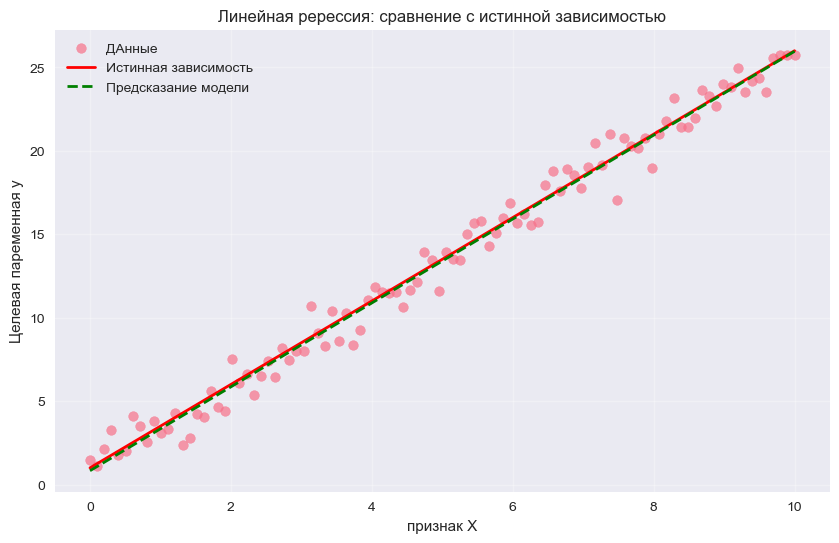

Метрики качества:
Mean Squared Error: 0.815
R² Score: 0.985


In [40]:
np.random.seed(42)

n_samples = 100
X = np.linspace(0,10, n_samples).reshape(-1,1)
true_w = 2.5
true_b = 1.0
y= true_w * X.flatten() +  true_b + np.random.normal(0, 1, n_samples)


plt.figure(figsize = (10,6))
plt.scatter(X, y, alpha = 0.7, label = 'Данные с шумом')
plt.plot(X, true_w * X + true_b , 'r-', linewidth = 2 , label = 'Истинная зависимость')
plt.xlabel('Признак X')
plt.ylabel("Целевая переменая")
plt.title('Синтетические данные для линейной регрессии') 
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()



model_lr = LinearRegression()
model_lr.fit(X, y)

y_pred = model_lr.predict(X)

print("Оцененные параметры модели:")
print(f"Смещение (intercept): {model_lr.intercept_:.3f}")
print(f"Коэффициент (slope): {model_lr.coef_[0]:.3f}")
print(f"Истинные параметры: смещение = {true_b}, коэффициент = {true_w}")


plt.figure(figsize = (10,6))
plt.scatter(X, y, alpha = 0.7, label = 'ДАнные')
plt.plot(X, true_w * X + true_b, 'r-' , linewidth = 2 , label = 'Истинная зависимость')
plt.plot(X, y_pred, 'g--' , linewidth = 2 , label = 'Предсказание модели')
plt.xlabel('признак X')
plt.ylabel('Целевая паременная y')
plt.title('Линейная ререссия: сравнение с истинной зависимостью')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()


mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)


print("Метрики качества:")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

**L2 - регуляризация (Ridge)**

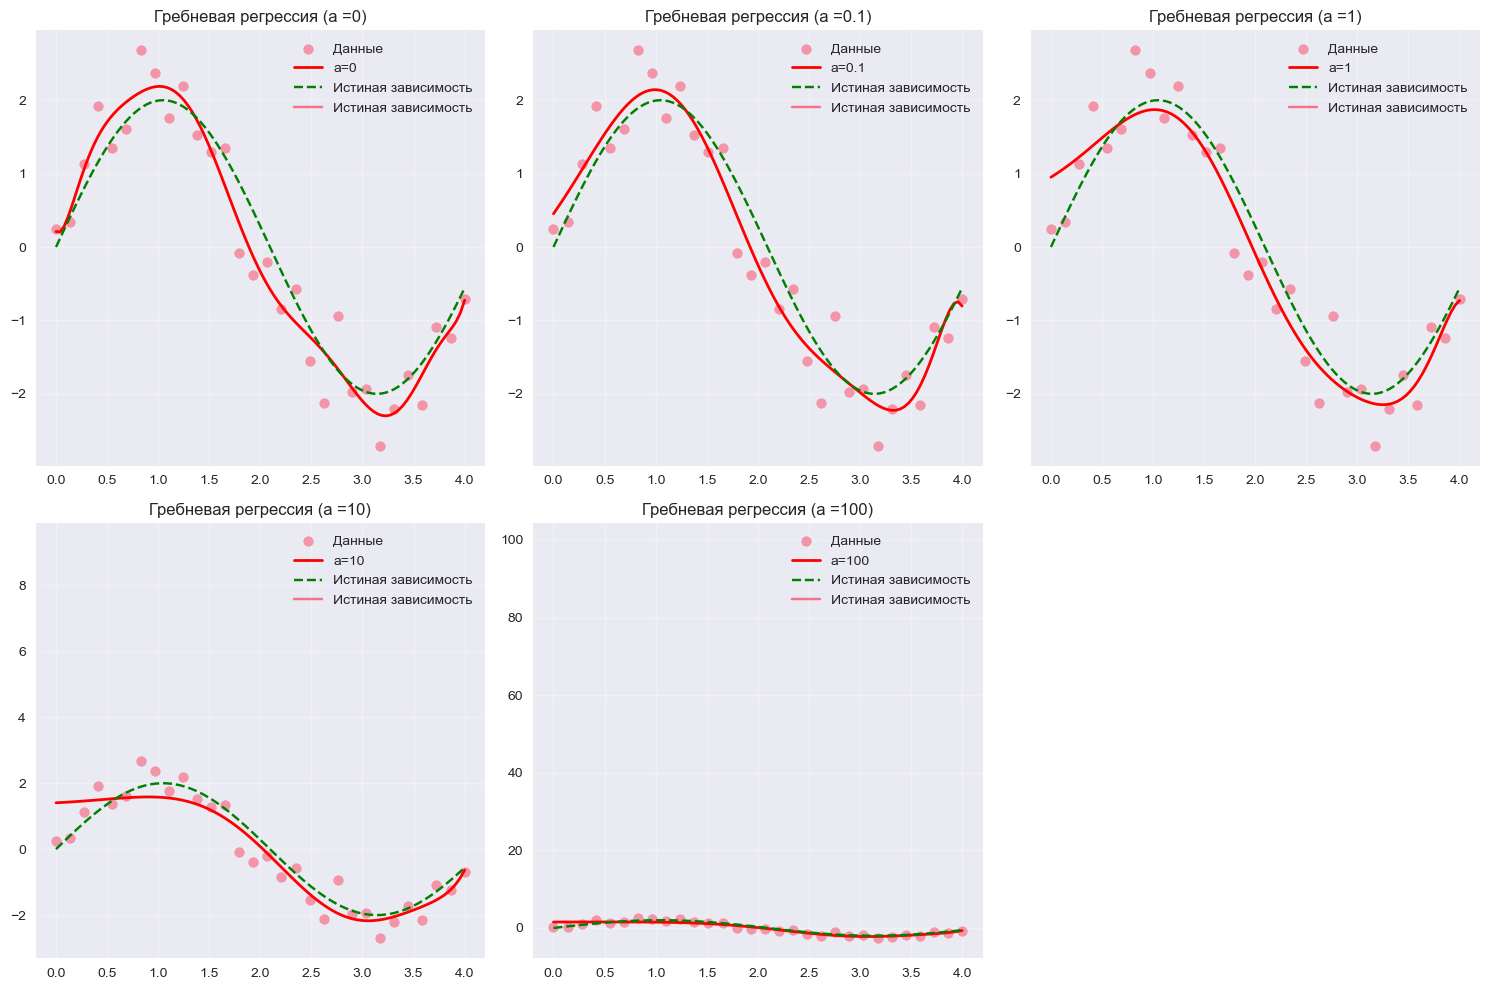

In [47]:
np.random.seed(42)
n_samples = 30 
X_complex = np.linspace( 0, 4, n_samples).reshape(-1,1)
y_complex = 2 * np.sin(1.5 * X_complex.flatten()) + np.random.normal(0, 0.5, n_samples)

poly = PolynomialFeatures(degree = 10, include_bias = False)
X_poly = poly.fit_transform(X_complex)

alphas = [0,0.1, 1,10, 100]
models_ridge = []
prediction_ridge = []


for alpha in alphas: 
    model = Ridge(alpha = alpha , random_state = 42)
    model.fit(X_poly , y_complex)
    models_ridge.append(model)


    X_test = np.linspace(0,4,100).reshape(-1, 1)
    X_test_poly = poly.transform(X_test)
    y_pred = model.predict(X_test_poly)
    prediction_ridge.append(y_pred)

plt.figure(figsize =(15,10))
for i , (alpha, y_pred) in enumerate(zip(alphas, prediction_ridge)): 
    plt.subplot(2,3,i+1)
    plt.scatter(X_complex, y_complex, alpha = 0.7 , label = 'Данные')
    X_plot = np.linspace(0, 4,100)
    plt.plot(X_plot, y_pred , 'r-' , linewidth = 2, label = f'a={alpha}')
    plt.plot(X_plot, 2 * np.sin(1.5 * X_plot) , 'g--' , alpha - 0.7, label = 'Истиная зависимость')
    plt.title(f'Гребневая регрессия (а ={alpha})')
    plt.legend()
    plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

    


**L1 - регуляризация**

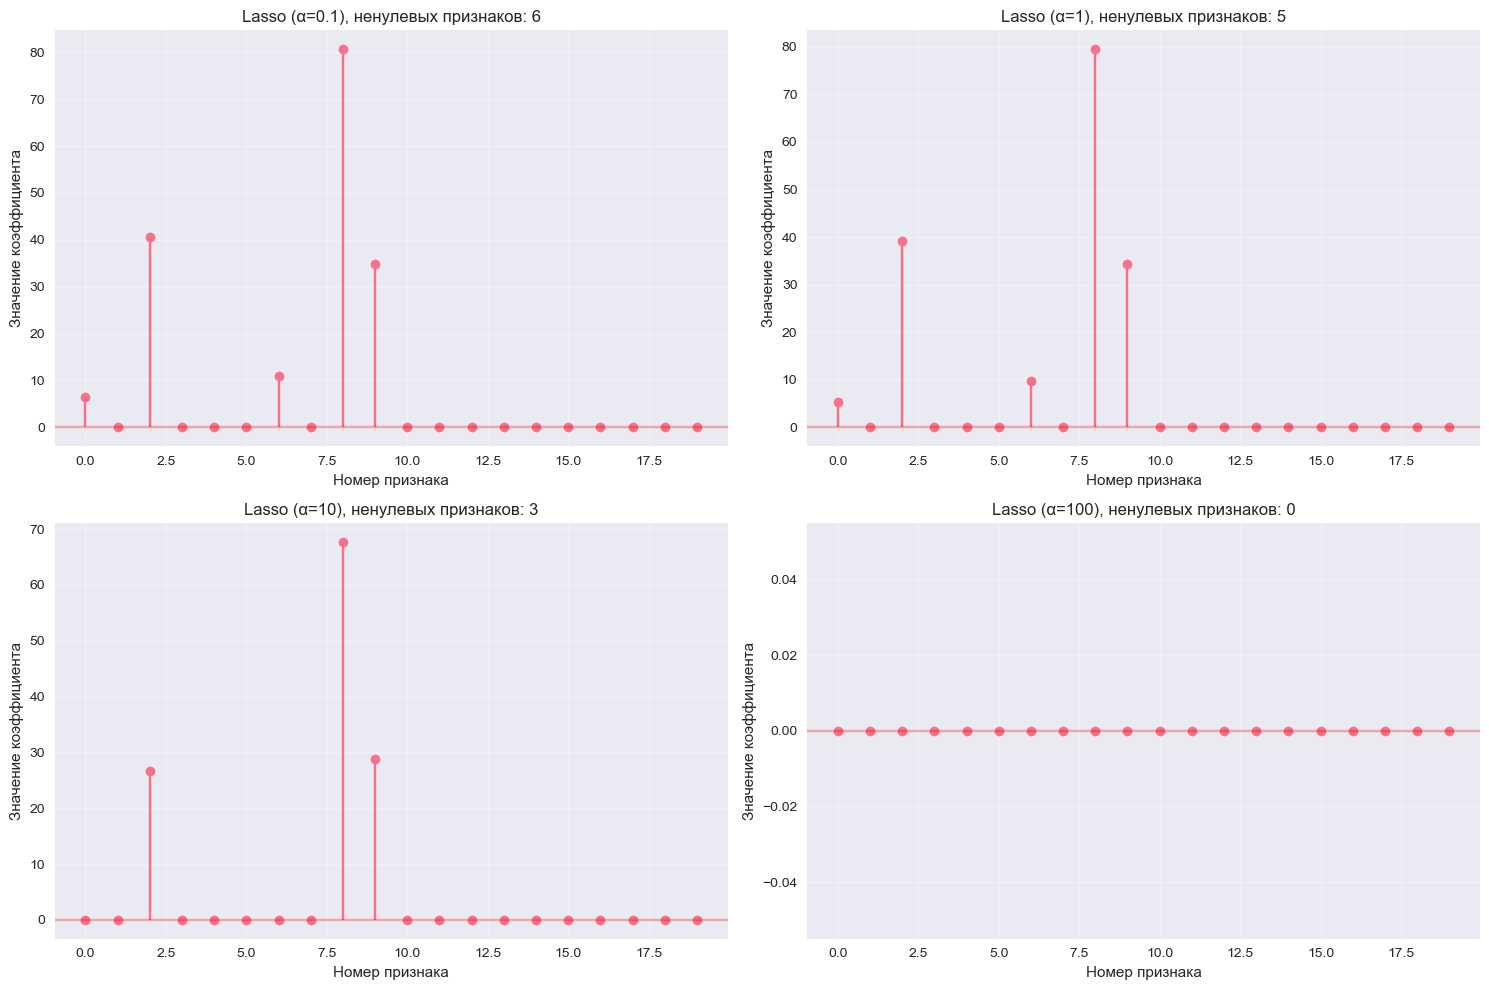

Отбор признаков Lasso:
α=0.1: используется 6 из 20 признаков
α=1: используется 5 из 20 признаков
α=10: используется 3 из 20 признаков
α=100: используется 0 из 20 признаков


In [58]:
np.random.seed(42)
n_features = 20
n_informative  = 5
X_high_dim, y_higt_dim = make_regression(n_samples = 100, 
                                         n_features=n_features, 
                                         n_informative = n_informative,
                                         noise = 0.5,
                                         random_state=42
                                        )
alphas_lasso= [0.1,1,10,100]
nonzero_coefs = []
plt.figure(figsize = (15, 10))

for i, alpha in enumerate(alphas_lasso):
    lasso = Lasso(alpha=alpha, random_state = 42)
    lasso.fit(X_high_dim, y_higt_dim)

    n_nonzero = np.sum(lasso.coef_ !=0)
    nonzero_coefs.append(n_nonzero)

    plt.subplot(2, 2, i+1)
    plt.stem(range(n_features), lasso.coef_, basefmt=" ")
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.title(f'Lasso (α={alpha}), ненулевых признаков: {n_nonzero}')
    plt.xlabel('Номер признака')
    plt.ylabel('Значение коэффициента')
    plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("Отбор признаков Lasso:")
for alpha, n_nonzero in zip(alphas_lasso, nonzero_coefs):
    print(f"α={alpha}: используется {n_nonzero} из {n_features} признаков")


**Регрессия опорных векторов**


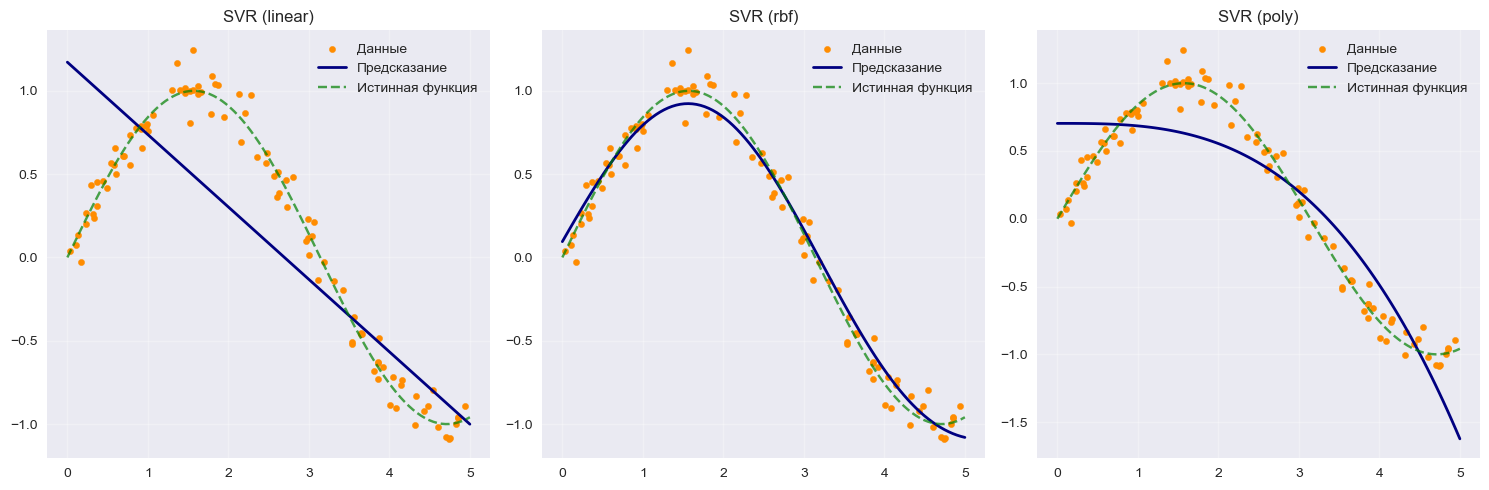

In [17]:

np.random.seed(42)


X_svr = np.sort(5 * np.random.rand(100, 1), axis=0)
y_svr = np.sin(X_svr).ravel() + np.random.normal(0, 0.1, X_svr.shape[0])


svr_models = {
    'SVR (linear)': SVR(kernel='linear', C=1.0),
    'SVR (rbf)': SVR(kernel='rbf', C=1.0, gamma=0.1),
    'SVR (poly)': SVR(kernel='poly', C=1.0, degree=3)
}

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(svr_models.items()):
    # Обучение
    model.fit(X_svr, y_svr)


    X_test = np.linspace(0, 5, 100).reshape(-1, 1)
    y_pred = model.predict(X_test)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_svr, y_svr, color='darkorange', label='Данные', s=20)
    
  
    plt.plot(X_test, y_pred, color='navy', lw=2, label='Предсказание')
    plt.plot(X_test, np.sin(X_test), 'g--', alpha=0.7, label='Истинная функция')
    
    plt.title(name)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Ансамбли моделей**

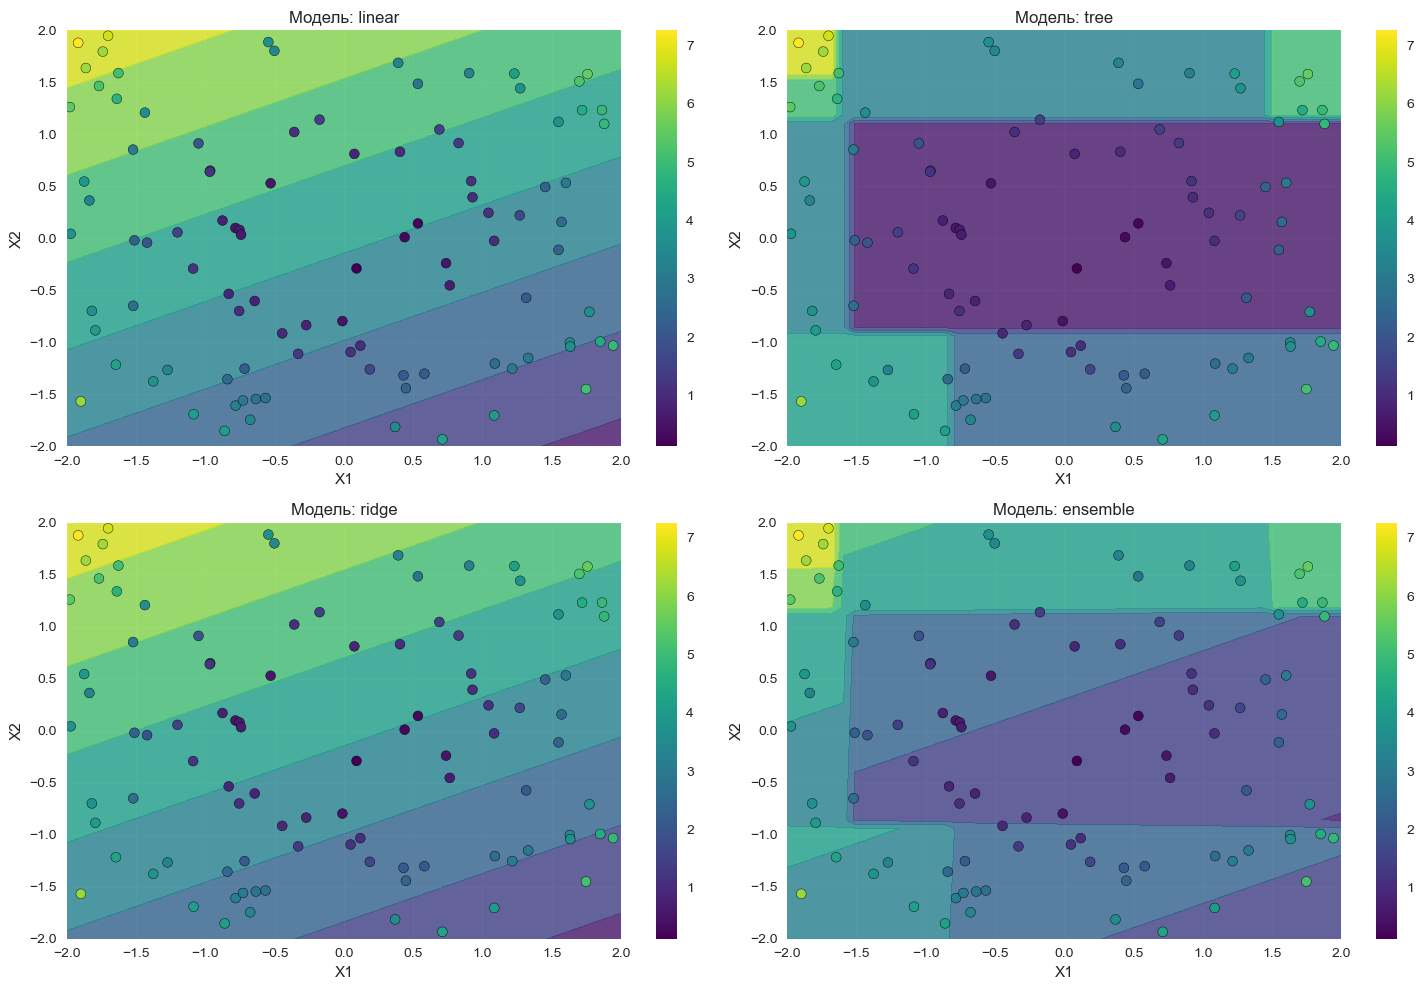

Сравнение качества моделей в ансамбле:
linear          | MSE:   2.6551 | R²:   0.0524
tree            | MSE:   0.8632 | R²:   0.6919
ridge           | MSE:   2.6551 | R²:   0.0524
ensemble        | MSE:   1.6732 | R²:   0.4028


In [24]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor

np.random.seed(42)
X_ensemble = np.random.rand(100, 2) * 4 - 2
y_ensemble = (X_ensemble[:, 0]**2 + X_ensemble[:, 1]**2 +
             np.random.normal(0, 0.1, 100))

base_models = [
    ('linear', LinearRegression()),
    ('tree', DecisionTreeRegressor(max_depth=3, random_state=42)),
    ('ridge', Ridge(alpha=1.0, random_state=42))
]

ensemble = VotingRegressor(estimators=base_models)

models_to_train = dict(base_models)
models_to_train['ensemble'] = ensemble

plt.figure(figsize=(15, 10))

xx, yy = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
X_grid = np.c_[xx.ravel(), yy.ravel()]

for i, (name, model) in enumerate(models_to_train.items()):
    model.fit(X_ensemble, y_ensemble)
    Z = model.predict(X_grid).reshape(xx.shape)

    plt.subplot(2, 2, i+1)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X_ensemble[:, 0], X_ensemble[:, 1], c=y_ensemble,
                edgecolors='black', s=50, cmap='viridis')
    plt.colorbar()
    plt.title(f'Модель: {name}')
    plt.xlabel('X1')
    plt.ylabel('X2')

plt.tight_layout()
plt.show()

print("Сравнение качества моделей в ансамбле:")
print("=" * 50)
for name, model in models_to_train.items():
    y_pred = model.predict(X_ensemble)
    mse = mean_squared_error(y_ensemble, y_pred)
    r2 = r2_score(y_ensemble, y_pred)
    print(f"{name:15} | MSE: {mse:8.4f} | R²: {r2:8.4f}")

**Работа с датасетом**

Размерность данных: (442, 10)
Количество признаков: 10
Целевая переменная: прогрессирование заболевания через год
Сравнение моделей на данных о диабете:
Модель               |  Train MSE |   Test MSE | Train R² |  Test R²
--------------------------------------------------------------------------------
Linear Regression    |    2868.55 |    2900.19 |    0.528 |    0.453
Ridge Regression     |    3388.18 |    3077.42 |    0.442 |    0.419
Lasso Regression     |    2935.26 |    2798.19 |    0.517 |    0.472
ElasticNet           |    5448.83 |    4775.47 |    0.103 |    0.099
SVR                  |    6085.74 |    5190.39 |   -0.002 |    0.020


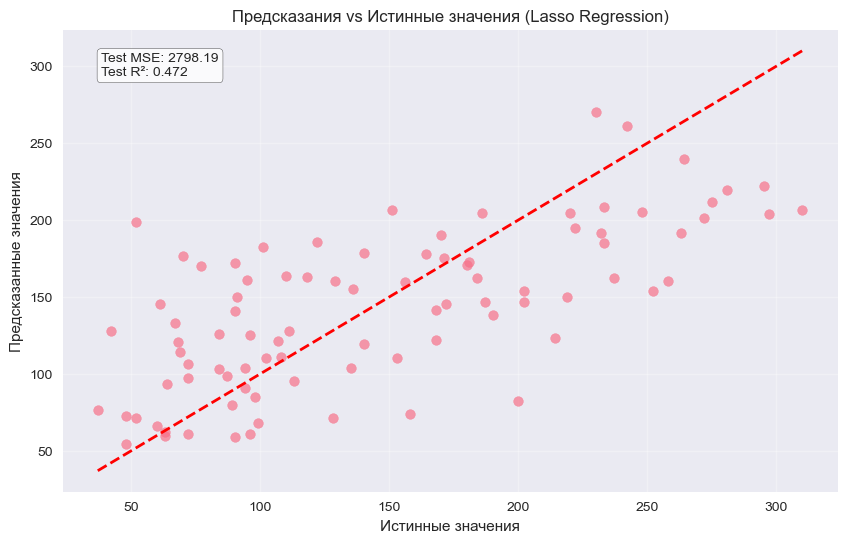

In [27]:


diabetes = load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target

print(f"Размерность данных: {X_diabetes.shape}")
print(f"Количество признаков: {X_diabetes.shape[1]}")
print(f"Целевая переменная: прогрессирование заболевания через год")

X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

final_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'SVR': SVR(kernel='linear', C=1.0)
}

final_results = {}
for name, model in final_models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    final_results[name] = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'model': model
    }

print("Сравнение моделей на данных о диабете:")
print("=" * 80)
print(f"{'Модель':20} | {'Train MSE':>10} | {'Test MSE':>10} | {'Train R²':>8} | {'Test R²':>8}")
print("-" * 80)
for name, results in final_results.items():
    print(f"{name:20} | {results['train_mse']:10.2f} | {results['test_mse']:10.2f} | "
          f"{results['train_r2']:8.3f} | {results['test_r2']:8.3f}")

best_model_name = min(final_results.keys(), key=lambda x: final_results[x]['test_mse'])
best_model = final_results[best_model_name]['model']
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания vs Истинные значения ({best_model_name})')
plt.grid(True, alpha=0.3)

metrics_text = (f'Test MSE: {final_results[best_model_name]["test_mse"]:.2f}\n'
                f'Test R²: {final_results[best_model_name]["test_r2"]:.3f}')
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.show()